# Pensjonsdemografi og pensjonsvolum

Denne notebooken analyserer ferdige Gold-data fra Pensjon Lakehouse-pipelinen.

Rapporten viser:

1. Utvikling i gjennomsnittlig pensjonsandel over tid
2. Kommuner med høyest andel innbyggere 55+
3. Næringer med høyest estimert pensjonsvolum
4. Sammenheng mellom antall lønnstakere og månedslønn per næring

Forutsetning:

```bash
python main.py
```

må være kjørt først, slik at Gold-data finnes under:

```text
/tmp/pensjon_lakehouse/gold/
```


## 1. Imports og paths

Notebooken leser kun ferdige Parquet-filer fra Gold-laget. Den henter ikke data fra SSB og kjører ikke selve lakehouse-pipelinen på nytt.


In [1]:
from pathlib import Path
import sys
print(sys.executable)

/Users/fredrik/anaconda3/bin/python


In [2]:

import duckdb
import pandas as pd
import matplotlib.pyplot as plt


In [3]:

LAKE = Path("/tmp/pensjon_lakehouse")
GOLD = LAKE / "gold"
REPORTS = LAKE / "reports"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

GOLD

PosixPath('/tmp/pensjon_lakehouse/gold')

## 2. Sjekk at Gold-data finnes

Hvis denne cellen feiler, kjør `python main.py` fra prosjektroten først.


In [4]:
required_files = [
    GOLD / "pensjonsandel_trend.parquet",
    GOLD / "top_kommuner_pensjonsalder.parquet",
    GOLD / "naering_pensjonsvolum.parquet",
]

missing_files = [file for file in required_files if not file.exists()]

if missing_files:
    raise FileNotFoundError(
        "Mangler Gold-filer. Kjør `python main.py` først.\n"
        + "\n".join(str(file) for file in missing_files)
    )

for file in required_files:
    print(file)


/tmp/pensjon_lakehouse/gold/pensjonsandel_trend.parquet
/tmp/pensjon_lakehouse/gold/top_kommuner_pensjonsalder.parquet
/tmp/pensjon_lakehouse/gold/naering_pensjonsvolum.parquet


## 3. Koble til DuckDB

Vi bruker DuckDB direkte i notebooken for å lese Parquet-filene.


In [5]:
db = duckdb.connect()


## 4. Pensjonsandel over tid

Denne delen viser hvordan gjennomsnittlig andel innbyggere 55+ utvikler seg over tid.


In [6]:
df_trend = db.execute(f"""
    SELECT
        year,
        snitt_pensjonsandel_pst,
        total_55_pluss,
        total_befolkning
    FROM read_parquet('{GOLD}/pensjonsandel_trend.parquet')
    ORDER BY year
""").fetchdf()

df_trend


,year,snitt_pensjonsandel_pst,total_55_pluss,total_befolkning
0,2022,36.16,1647864.0,5425270.0
1,2023,36.47,1682839.0,5488984.0
2,2024,36.76,1721384.0,5550203.0
3,2025,37.22,1758689.0,5594340.0
4,2026,37.60,1792105.0,5627400.0


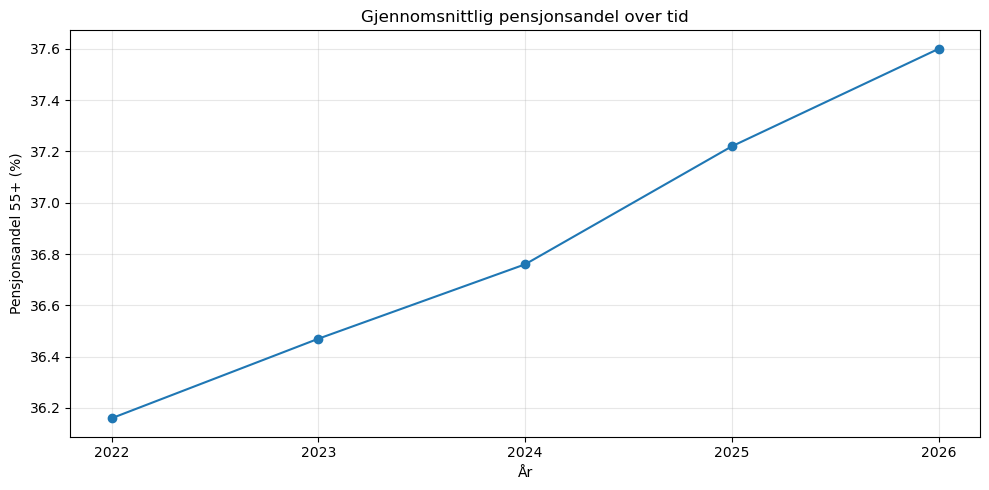

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_trend["year"],
    df_trend["snitt_pensjonsandel_pst"],
    marker="o",
)

plt.title("Gjennomsnittlig pensjonsandel over tid")
plt.xlabel("År")
plt.ylabel("Pensjonsandel 55+ (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Kommuner med høyest andel 55+

Her ser vi hvilke kommuner som har størst andel innbyggere i aldersgruppen 55+.


In [8]:
df_kommuner = db.execute(f"""
    WITH top10 AS (
        SELECT
            kommune_label,
            total_befolkning,
            pension_age_befolkning,
            CAST(ROUND(pension_age_share * 100, 1) AS DECIMAL(5, 1)) AS andel_55_pluss
        FROM read_parquet('{GOLD}/top_kommuner_pensjonsalder.parquet')
        ORDER BY pension_age_share DESC
        LIMIT 10
    )
    SELECT *
    FROM top10
    ORDER BY andel_55_pluss ASC
""").fetchdf()

df_kommuner


,kommune_label,total_befolkning,pension_age_befolkning,andel_55_pluss
0,Beiarn,1032.0,496.0,48.1
1,Bindal,1361.0,656.0,48.2
2,Stor-Elvdal,2239.0,1079.0,48.2
3,Grue,4463.0,2174.0,48.7
4,Engerdal,1287.0,628.0,48.8
5,Tydal,773.0,379.0,49.0
6,Rendalen,1836.0,906.0,49.3
7,Lødingen,1964.0,986.0,50.2
8,Ibestad,1287.0,654.0,50.8
9,Hvaler,4714.0,2412.0,51.2


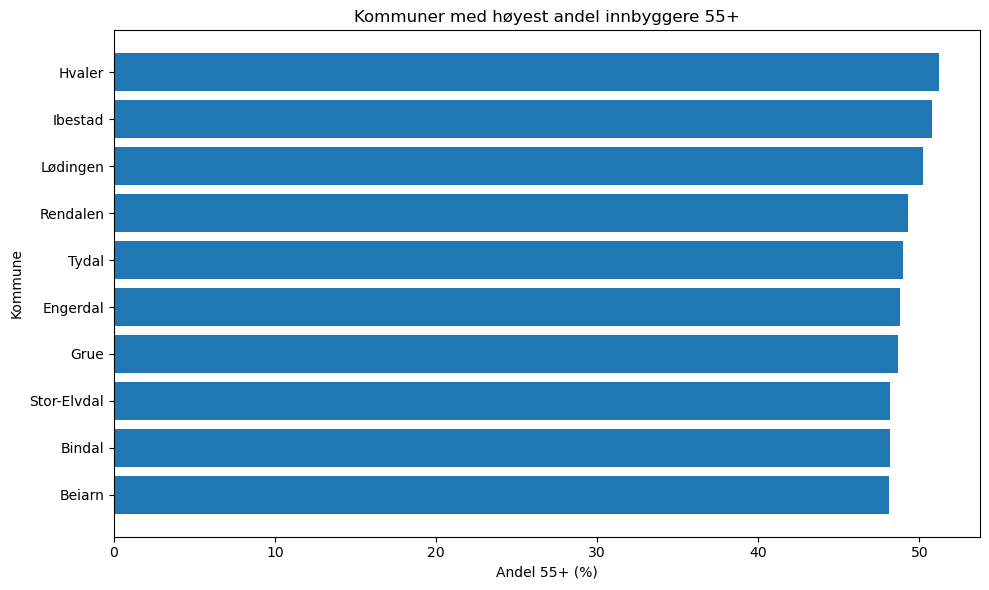

In [9]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_kommuner["kommune_label"],
    df_kommuner["andel_55_pluss"],
)

plt.title("Kommuner med høyest andel innbyggere 55+")
plt.xlabel("Andel 55+ (%)")
plt.ylabel("Kommune")
plt.tight_layout()
plt.show()


## 6. Næringer med høyest estimert pensjonsvolum

Estimert pensjonsvolum er beregnet i pipelinen som:


$\mathit{Estimert\ pensjonsvolum} = \mathit{lønnstakere} \cdot \mathit{månedslønn} \cdot 12 \cdot 0.02$


`Alle næringer` ekskluderes her fordi det er en totalsum, ikke en enkelt næring.


In [10]:
df_naering = db.execute(f"""
    WITH top10 AS (
        SELECT
            naering_label,
            lonsstakere,
            manedslonn,
            estimert_pensjonsvolum,
            estimert_pensjonsvolum / 1000000000 AS estimert_pensjonsvolum_mrd
        FROM read_parquet('{GOLD}/naering_pensjonsvolum.parquet')
        WHERE naering_label <> 'Alle næringer'
        ORDER BY estimert_pensjonsvolum DESC
        LIMIT 10
    )
    SELECT *
    FROM top10
    ORDER BY estimert_pensjonsvolum_mrd ASC
""").fetchdf()

df_naering


,naering_label,lonsstakere,manedslonn,estimert_pensjonsvolum,estimert_pensjonsvolum_mrd
0,Forretningsmessig tjenesteyting,139426,57220,1.914709e+09,1.914709
1,Transport og lagring,136108,61440,2.006994e+09,2.006994
2,Informasjon og kommunikasjon,112594,83440,2.254762e+09,2.254762
3,"Off.adm., forsvar, sosialforsikring",186074,67810,3.028243e+09,3.028243
4,Undervisning,229643,58690,3.234659e+09,3.234659
5,"Teknisk tjenesteyting, eiendomsdrift",182903,76780,3.370390e+09,3.370390
6,Industri,227217,63510,3.463332e+09,3.463332
7,Bygge- og anleggsvirksomhet,235240,61400,3.466497e+09,3.466497
8,"Varehandel, reparasjon av motorvogner",353894,57680,4.899025e+09,4.899025
9,Helse- og sosialtjenester,589694,56980,8.064183e+09,8.064183


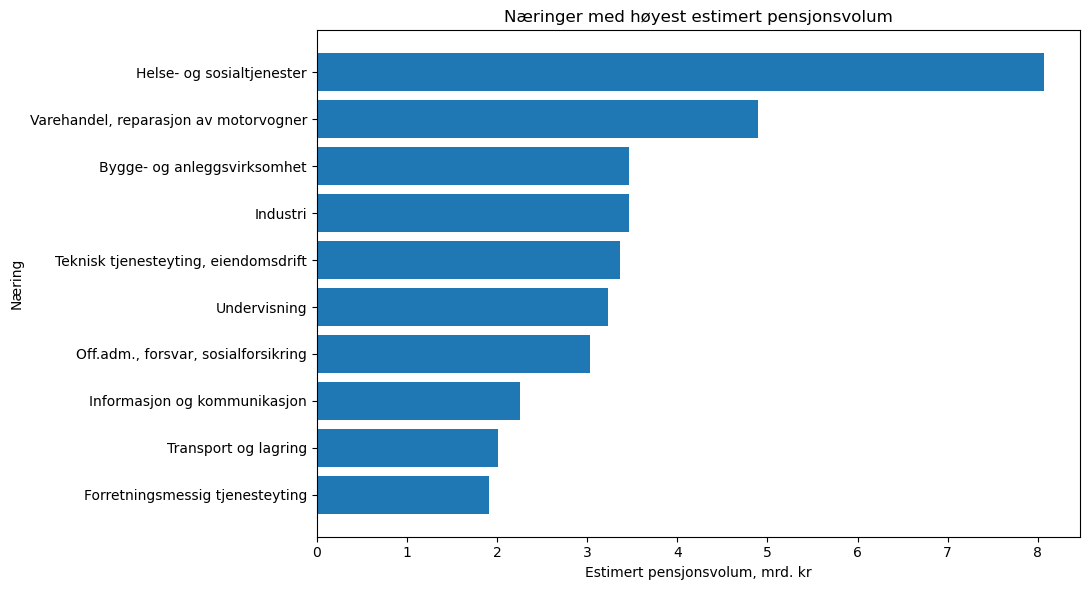

In [11]:
plt.figure(figsize=(11, 6))

plt.barh(
    df_naering["naering_label"],
    df_naering["estimert_pensjonsvolum_mrd"],
)

plt.title("Næringer med høyest estimert pensjonsvolum")
plt.xlabel("Estimert pensjonsvolum, mrd. kr")
plt.ylabel("Næring")
plt.tight_layout()
plt.show()


## 7. Lønnstakere og månedslønn per næring

Denne figuren gir et ekstra blikk på hva som driver pensjonsvolumet: mange ansatte, høy månedslønn, eller en kombinasjon.


In [12]:
df_naering_scatter = db.execute(f"""
    SELECT
        naering_label,
        lonsstakere,
        manedslonn,
        estimert_pensjonsvolum / 1000000000 AS estimert_pensjonsvolum_mrd
    FROM read_parquet('{GOLD}/naering_pensjonsvolum.parquet')
    WHERE naering_label <> 'Alle næringer'
    ORDER BY estimert_pensjonsvolum DESC
""").fetchdf()

df_naering_scatter


,naering_label,lonsstakere,manedslonn,estimert_pensjonsvolum_mrd
0,Helse- og sosialtjenester,589694,56980,8.064183
1,"Varehandel, reparasjon av motorvogner",353894,57680,4.899025
2,Bygge- og anleggsvirksomhet,235240,61400,3.466497
3,Industri,227217,63510,3.463332
4,"Teknisk tjenesteyting, eiendomsdrift",182903,76780,3.370390
5,Undervisning,229643,58690,3.234659
6,"Off.adm., forsvar, sosialforsikring",186074,67810,3.028243
7,Informasjon og kommunikasjon,112594,83440,2.254762
8,Transport og lagring,136108,61440,2.006994
9,Forretningsmessig tjenesteyting,139426,57220,1.914709


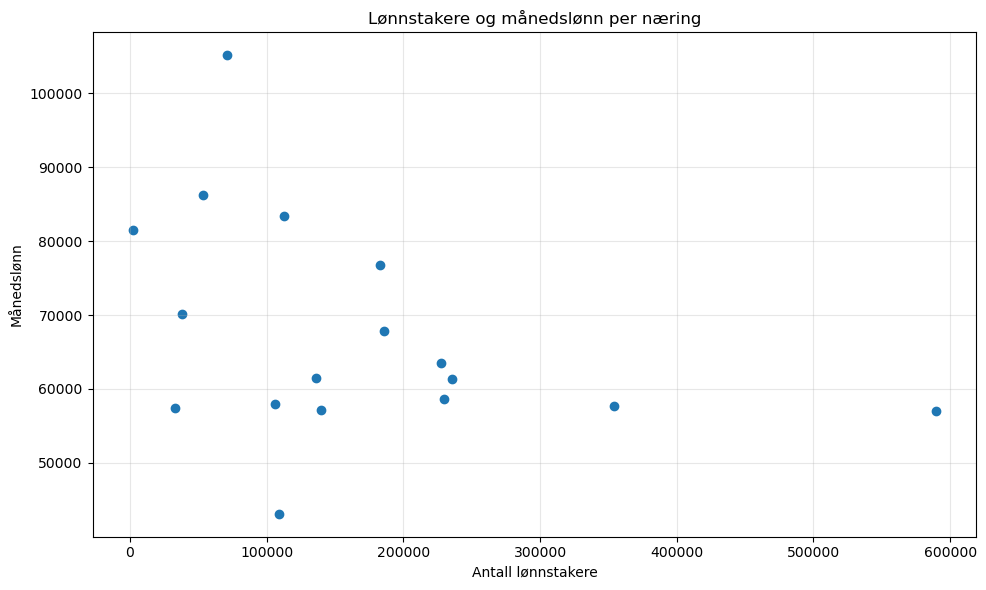

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_naering_scatter["lonsstakere"],
    df_naering_scatter["manedslonn"],
)

plt.title("Lønnstakere og månedslønn per næring")
plt.xlabel("Antall lønnstakere")
plt.ylabel("Månedslønn")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Kort oppsummering

Denne cellen trekker ut noen nøkkelpunkter fra analysen.


In [14]:
latest_year = df_trend["year"].max()
latest_share = df_trend.loc[
    df_trend["year"] == latest_year,
    "snitt_pensjonsandel_pst",
].iloc[0]

top_kommune = df_kommuner.sort_values(
    "andel_55_pluss",
    ascending=False,
).iloc[0]

top_naering = df_naering.sort_values(
    "estimert_pensjonsvolum_mrd",
    ascending=False,
).iloc[0]

print(f"Siste år i datasettet er {latest_year}.")
print(f"Gjennomsnittlig pensjonsandel er {latest_share:.1f} %.")
print(
    f"Kommunen med høyest andel 55+ er {top_kommune['kommune_label']} "
    f"med {float(top_kommune['andel_55_pluss']):.1f} %."
)
print(
    f"Næringen med høyest estimert pensjonsvolum er "
    f"{top_naering['naering_label']} "
    f"med ca. {top_naering['estimert_pensjonsvolum_mrd']:.1f} mrd. kr."
)


Siste år i datasettet er 2026.
Gjennomsnittlig pensjonsandel er 37.6 %.
Kommunen med høyest andel 55+ er Hvaler med 51.2 %.
Næringen med høyest estimert pensjonsvolum er Helse- og sosialtjenester med ca. 8.1 mrd. kr.


## 9. Valgfritt: lagre grafene som PNG

Denne cellen lagrer de tre viktigste grafene til `/tmp/pensjon_lakehouse/reports/`.


In [15]:
REPORTS.mkdir(parents=True, exist_ok=True)

# Pensjonsandel over tid
plt.figure(figsize=(10, 5))
plt.plot(df_trend["year"], df_trend["snitt_pensjonsandel_pst"], marker="o")
plt.title("Gjennomsnittlig pensjonsandel over tid")
plt.xlabel("År")
plt.ylabel("Pensjonsandel 55+ (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "pensjonsandel_trend.png", dpi=150)
plt.close()

# Kommuner med høyest andel 55+
plt.figure(figsize=(10, 6))
plt.barh(df_kommuner["kommune_label"], df_kommuner["andel_55_pluss"])
plt.title("Kommuner med høyest andel innbyggere 55+")
plt.xlabel("Andel 55+ (%)")
plt.ylabel("Kommune")
plt.tight_layout()
plt.savefig(REPORTS / "kommuner_hoyest_andel_55_pluss.png", dpi=150)
plt.close()

# Næringer med høyest estimert pensjonsvolum
plt.figure(figsize=(11, 6))
plt.barh(df_naering["naering_label"], df_naering["estimert_pensjonsvolum_mrd"])
plt.title("Næringer med høyest estimert pensjonsvolum")
plt.xlabel("Estimert pensjonsvolum, mrd. kr")
plt.ylabel("Næring")
plt.tight_layout()
plt.savefig(REPORTS / "naeringer_hoyest_estimert_pensjonsvolum.png", dpi=150)
plt.close()

print(f"Grafer lagret i: {REPORTS}")


Grafer lagret i: /tmp/pensjon_lakehouse/reports


## 10. Lukk DuckDB-forbindelsen


In [16]:
db.close()
